In [1]:
import io
from array import array

import matplotlib.pyplot as plt
from ase import Atoms
from ase.optimize import FIRE
from ase.visualize import view
from orb_models.forcefield.inference.calculator import ORBCalculator
from orb_models.forcefield.pretrained import orbmol_v2
from tqdm.auto import tqdm

In [2]:
atoms_ammonium = Atoms(
    "NH4",
    positions=[
        (0.000, 0.000, 0.000),  # N
        (0.629, 0.629, 0.629),
        (-0.629, -0.629, 0.629),
        (-0.629, 0.629, -0.629),
        (0.629, -0.629, -0.629),
    ],
)
atoms_ammonium.info["charge"] = 1
atoms_ammonium.info["spin"] = 1

view(atoms_ammonium, viewer="ngl")

In [3]:
device = "cuda"

model, atoms_adapter = orbmol_v2(
    "./checkpoints/orbmol-v2-teqabfhg-20260523.ckpt", device=device
)

/home/yu9824/opt/miniforge3/envs/orbmolv2_312/lib/python3.12/site-packages/orb_models/common/training/util.py:20: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


In [4]:
calc = ORBCalculator(model, atoms_adapter=atoms_adapter, device=device)
atoms_ammonium.calc = calc


In [5]:
atoms_ammonium.get_potential_energy()

-1547.5526113510132

以下の条件で計算

> 分子の配置は分子間の距離がそれぞれ10 nmとなるように直線状に配置した。構造最適化はASEライブラリのFIRE法を使い、力の収束条件を fmax=0.01 (eV/Å, 1 Å=0.1 nm) とした。
> 
> <cite>https://tech.preferred.jp/ja/blog/%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%9D%E3%83%86%E3%83%B3%E3%82%B7%E3%83%A3%E3%83%AB%E3%81%AE%E8%BF%91%E4%BC%BC%E3%81%AE%E9%99%90%E7%95%8C%E3%82%92%E8%B6%85%E3%81%88%E3%81%A6%E3%80%90%E3%82%A4/</cite>

In [6]:
spacing = 100.0  # 10 nm
force_threshold = 0.01

n_mol_list = range(1, 11)

energies_charge_state_orbmolv2 = array("f")
energies_spin_state_orbmolv2 = array("f")
n_molecules_array = array("I", n_mol_list)

for n_molecules in tqdm(n_mol_list):
    print(f"{n_molecules=}")

    system = Atoms()

    # build linear chain
    for i in range(n_molecules):
        mol = atoms_ammonium.copy()
        mol.translate([i * spacing])
        system += mol

    assert len(system) == n_molecules * len(atoms_ammonium)

    # -------------------------
    # charged state calculation
    # -------------------------
    system_charge = system.copy()
    system_charge.info["charge"] = n_molecules
    system_charge.info["spin"] = 1
    system_charge.calc = calc

    opt = FIRE(system_charge)
    opt.run(fmax=force_threshold)

    energies_charge_state_orbmolv2.append(system_charge.get_potential_energy())

    # -------------------------
    # spin state calculation
    # -------------------------
    system_spin = system.copy()
    system_spin.info["charge"] = 0
    system_spin.info["spin"] = n_molecules + 1
    system_spin.calc = calc

    opt = FIRE(system_spin)
    opt.run(fmax=force_threshold)

    energies_spin_state_orbmolv2.append(system_spin.get_potential_energy())

energies_charge_per_mol_orbmolv2 = array(
    "f",
    [e / n for n, e in zip(n_mol_list, energies_charge_state_orbmolv2)],
)

energies_spin_per_mol_orbmolv2 = array(
    "f",
    [e / n for n, e in zip(n_mol_list, energies_spin_state_orbmolv2)],
)

  0%|          | 0/10 [00:00<?, ?it/s]

n_molecules=1
      Step     Time          Energy          fmax
FIRE:    0 23:17:18    -1547.552611        2.301840
FIRE:    1 23:17:18    -1547.733132        1.607998
FIRE:    2 23:17:18    -1547.876840        0.172082
FIRE:    3 23:17:18    -1547.753492        1.770141
FIRE:    4 23:17:19    -1547.781864        1.534446
FIRE:    5 23:17:19    -1547.826442        1.114931
FIRE:    6 23:17:19    -1547.863342        0.580959
FIRE:    7 23:17:19    -1547.878656        0.023169
FIRE:    8 23:17:19    -1547.865641        0.497548
FIRE:    9 23:17:19    -1547.866785        0.484757
FIRE:   10 23:17:19    -1547.867968        0.460270
FIRE:   11 23:17:19    -1547.869102        0.423384
FIRE:   12 23:17:19    -1547.870409        0.376566
FIRE:   13 23:17:19    -1547.873570        0.318799
FIRE:   14 23:17:19    -1547.875344        0.255523
FIRE:   15 23:17:19    -1547.877225        0.181436
FIRE:   16 23:17:19    -1547.877201        0.096608
FIRE:   17 23:17:19    -1547.877966        0.005806


In [7]:
# reference: https://tech.preferred.jp/ja/blog/%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%9D%E3%83%86%E3%83%B3%E3%82%B7%E3%83%A3%E3%83%AB%E3%81%AE%E8%BF%91%E4%BC%BC%E3%81%AE%E9%99%90%E7%95%8C%E3%82%92%E8%B6%85%E3%81%88%E3%81%A6%E3%80%90%E3%82%A4/
energies_charge_per_mol_uma1p2 = array(
    "f",
    [
        -1547.90,
        -1547.20,
        -1546.82,
        -1546.58,
        -1545.63,
        -1544.58,
        -1543.73,
        -1542.76,
        -1541.87,
        -1541.02,
    ],
)
energies_spin_per_mol_uma1p2 = array(
    "f",
    [
        -1552.17,
        -1550.30,
        -1551.54,
        -1551.78,
        -1551.99,
        -1552.03,
        -1552.08,
        -1551.96,
        -1551.80,
        -1551.77,
    ],
)


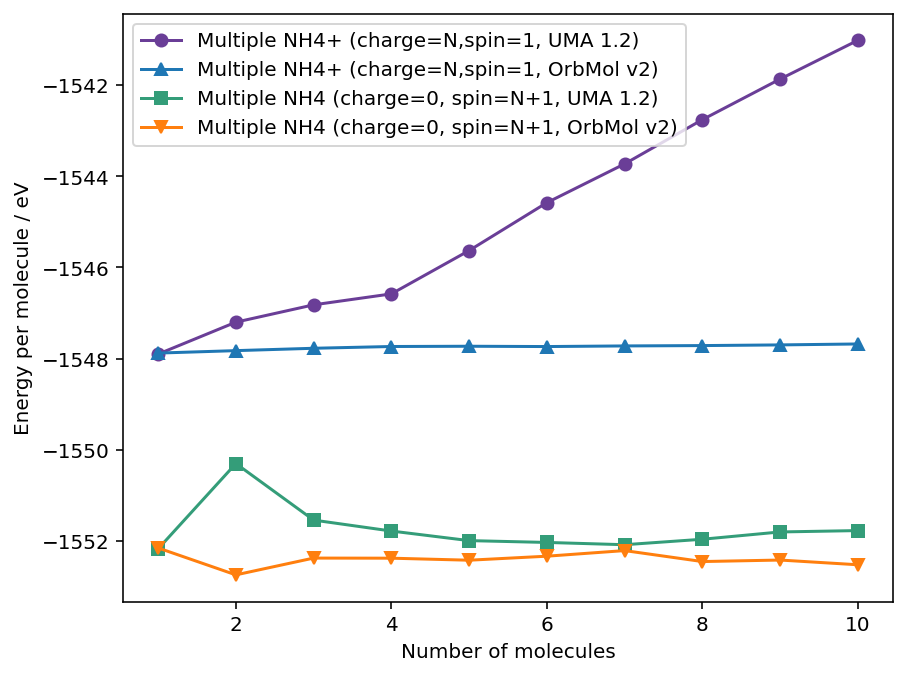

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=144)
ax.plot(
    n_molecules_array,
    energies_charge_per_mol_uma1p2,
    label="Multiple NH4+ (charge=N,spin=1, UMA 1.2)",
    marker="o",
    color="#6a3e97",
)
ax.plot(
    n_molecules_array,
    energies_charge_per_mol_orbmolv2,
    label="Multiple NH4+ (charge=N,spin=1, OrbMol v2)",
    marker="^",
)
ax.plot(
    n_molecules_array,
    energies_spin_per_mol_uma1p2,
    label="Multiple NH4 (charge=0, spin=N+1, UMA 1.2)",
    marker="s",
    color="#349d79",
)
ax.plot(
    n_molecules_array,
    energies_spin_per_mol_orbmolv2,
    label="Multiple NH4 (charge=0, spin=N+1, OrbMol v2)",
    marker="v",
)
ax.set_xlabel("Number of molecules")
ax.set_ylabel("Energy per molecule / eV")
ax.legend()
fig.tight_layout()